### 馬達論文研究
### 第三步 遷移式學習
### 馬達C 8000RPM 當作基準模型
### 8000 RPM 可能是最適合巡航的轉速，因為它提供足夠的推力又不會過度耗電。
### CNN_11 Layers

In [ ]:
# --- logging bootstrap (auto-added) ---
import atexit
from logger import redirect_std_to_logger, save_plot, setup_logger

LOG, RUN_PATHS = setup_logger('notebook')
_redirect_ctx = redirect_std_to_logger(LOG)
_redirect_ctx.__enter__()
atexit.register(_redirect_ctx.__exit__, None, None, None)

# Auto-save matplotlib figures on plt.show()
try:
    import matplotlib.pyplot as plt
    _orig_show = plt.show

    def _show_and_save(*args, **kwargs):
        try:
            save_plot(plt, LOG, RUN_PATHS)
        except Exception:
            pass
        return _orig_show(*args, **kwargs)

    plt.show = _show_and_save
except Exception:
    pass
# --- end logging bootstrap ---


In [6]:
# 匯入所需函式庫
import os
import logging
import absl.logging
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder, RobustScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input, Concatenate, Add, Activation, GlobalAveragePooling1D, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
from gpu_utils import device_scope, DEVICE
warnings.filterwarnings("ignore")

In [7]:
# 資料準備與處理
def load_and_preprocess_data(base_dir, screws_list):
    datasets = []
    for screws in screws_list:
        file_path = os.path.join(base_dir, 'T1', '8000rpm', screws, 'T1_Group_feature_data.csv')
        if os.path.exists(file_path):
            dataset = pd.read_csv(file_path)
            dataset['screws'] = screws
            datasets.append(dataset)
        else:
            print(f"檔案未找到: {file_path}")
    return datasets

In [8]:
# 加載資料
rootDir = os.getcwd()
dataDir = os.path.join(rootDir, 'data')
stepDir = os.path.join(dataDir, 'Step-1')
modelDirectory = os.path.join(stepDir, 'model')
myfeatureDirectory = os.path.join(stepDir, 'myfeature')

screws_list = ['8screws', '1screws', '2screws', '3screws', '4screws']
datasets_T1 = load_and_preprocess_data(myfeatureDirectory, screws_list)

In [9]:
# 合併資料
combined_data = pd.concat(datasets_T1, ignore_index=True)

In [10]:
# **手動定義標籤順序**
desired_order = ['8screws', '1screws', '2screws', '3screws', '4screws']
label_mapping = {screw: idx for idx, screw in enumerate(desired_order)}
combined_data['screws'] = combined_data['screws'].map(label_mapping)

In [11]:
# 標籤編碼
le_screws = LabelEncoder()
combined_data['screws'] = le_screws.fit_transform(combined_data['screws'])

In [12]:
# 確認標籤映射是否正確
print("自訂 Label Mapping:")
for label, num in label_mapping.items():
    print(f"{label}: {num}")

In [13]:
# 資料分割
X = combined_data.drop(['screws'], axis=1).values
y_screws = combined_data['screws'].values

In [14]:
# 劃分訓練與測試集
X_train, X_test, y_train_screws, y_test_screws = train_test_split(
    X, y_screws, test_size=0.2, random_state=42
)

In [15]:
# 標準化特徵
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# 建立 CNN 模型
def build_cnn_model(input_shape, num_classes):

    # 定義輸入層
    input_layer = tf.keras.Input(shape=input_shape)

    # 第一層卷積層
    x = Conv1D(16, kernel_size=3, activation='relu', padding='same')(input_layer)

    # 第二層卷積層
    x = Conv1D(16, kernel_size=3, activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)

    # 第三層卷積層
    x = Conv1D(16, kernel_size=3, activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)

    # 第四層卷積層
    x = Conv1D(16, kernel_size=3, activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)

    x = Flatten()(x)

    # 第五層卷積層
    x = Dense(16, activation='relu')(x)
    x = Dropout(0.3)(x)

    # 第六層卷積層
    output = Dense(num_classes, activation='softmax', name="Screw_Number_Output")(x)


    # 定義模型    
    model = Model(inputs=input_layer, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=["sparse_categorical_crossentropy"],
        metrics=["accuracy"]
    )
    return model


In [17]:
# 模型參數
num_classes = len(np.unique(y_train_screws))

In [18]:
print(f"[Training] Device: {DEVICE}")
with device_scope():
    # 建立 CNN 模型
    cnn_model = build_cnn_model((X_train.shape[1], 1), num_classes)
    
    # 訓練模型
    history = cnn_model.fit(
        X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
        y_train_screws,
        validation_data=(
            X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
            y_test_screws
        ),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    )

In [19]:
# 清除
tf.keras.backend.clear_session()

In [20]:
# 模型架構
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 105, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 105, 16)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 103, 16)        │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 51, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 49, 16)         │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 24, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 22, 16)         │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 11, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         2,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Screw_Number_Output (Dense)     │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,001 (62.51 KB)

 Trainable params: 5,333 (20.83 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,668 (41.68 KB)

In [21]:
# 評估模型
results = cnn_model.evaluate(
    X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
    y_test_screws
)
print(f"Loss: {results[0]:.4f}, Accuracy: {results[1]:.4f}")

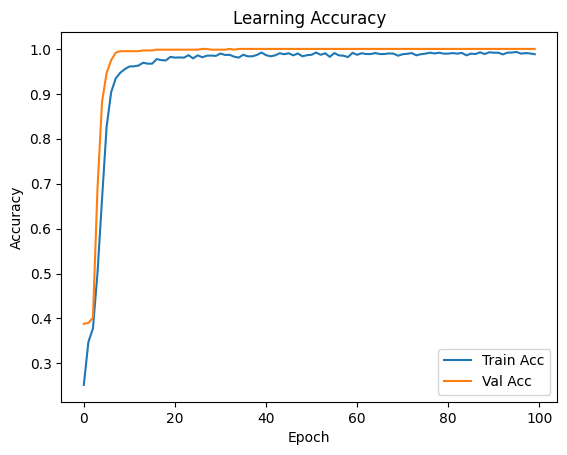

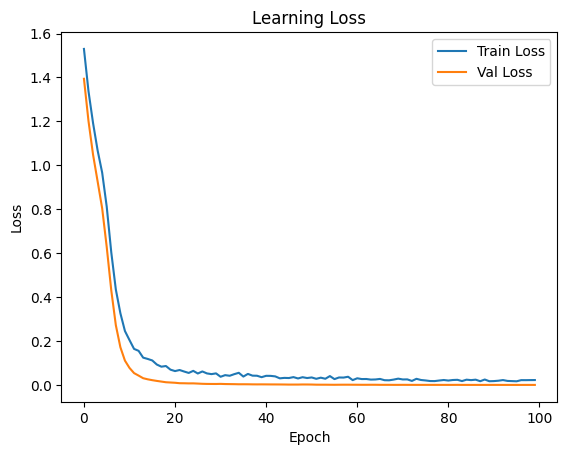

In [22]:
# 繪製學習曲線
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

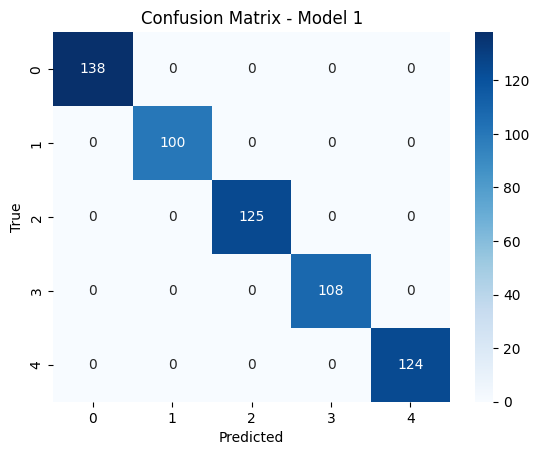

In [23]:
# 混淆矩陣繪製
def plot_confusion_matrix(y_true, y_pred, label_encoder, title):
    """
    繪製混淆矩陣，顯示數字映射標籤
    """
    cm = confusion_matrix(y_true, y_pred)
    numeric_labels = range(len(label_encoder.classes_))  # 使用數字標籤
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=numeric_labels, yticklabels=numeric_labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# 預測並繪製混淆矩陣
y_pred_screw = cnn_model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1)).argmax(axis=1)
plot_confusion_matrix(y_test_screws, y_pred_screw, le_screws, "Confusion Matrix - Model 1")

In [24]:
# 儲存模型
cnn_model.save(os.path.join(modelDirectory, 'CNN_C8000.keras'))